In [ ]:
import math
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
G = 1.0  

def accelerations(positions, masses):
    """
    positions: (N, 2) массив координат [x, y]
    masses: (N,) массив масс
    return: (N, 2) ускорения
    """
    N = len(masses)
    acc = np.zeros_like(positions)
    for i in range(N):
        for j in range(N):
            if i != j:
                r_vec = positions[j] - positions[i]
                r = np.linalg.norm(r_vec)
                acc[i] += G * masses[j] * r_vec / r**3
    return acc



def rk4_step(state, dt, masses):
    N = len(masses)
    def f(state):
        pos = state[:N]
        vel = state[N:]
        acc = accelerations(pos, masses)
        return np.vstack([vel, acc])

    k1 = f(state)
    k2 = f(state + 0.5 * dt * k1)
    k3 = f(state + 0.5 * dt * k2)
    k4 = f(state + dt * k3)

    return state + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


def simulate(method_step, dt, t_end, masses, pos0, vel0):
    """
    pos0: (N,2) начальные координаты
    vel0: (N,2) начальные скорости
    """
    N = len(masses)
    steps = int(np.floor(t_end/dt)) + 1
    t = np.array([i*dt for i in range(steps)])

    # состояние: (2N, 2), сначала позиции, потом скорости
    state = np.vstack([pos0, vel0])

    positions = np.zeros((steps, N, 2))
    velocities = np.zeros((steps, N, 2))

    for i in range(steps):
        positions[i] = state[:N]
        velocities[i] = state[N:]
        state = method_step(state, dt, masses)

    return positions, velocities, t


In [3]:
masses = np.array([1.0, 1.0, 1.0])  
pos0 = np.array([[0, 0], [1, 0], [1, 1]], dtype=float)  
vel0 = np.array([[0, 0], [0, 0], [0, 0]], dtype=float)    

positions, velocities, t = simulate(rk4_step, dt=0.001, t_end=10, masses=masses, pos0=pos0, vel0=vel0)
speed = np.linalg.norm(velocities, axis=2)

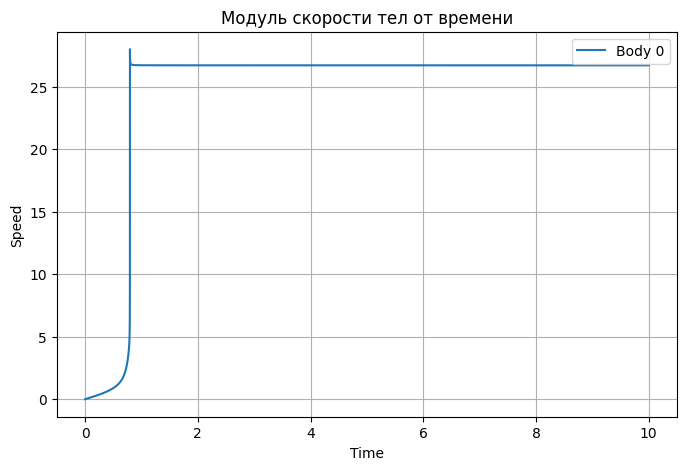

In [4]:
plt.figure(figsize=(8,5))

plt.plot(t, speed[:, 0], label=f'Body 0')
plt.xlabel("Time")
plt.ylabel("Speed")
plt.title("Модуль скорости тел от времени")
plt.legend()
plt.grid(True)
plt.show()

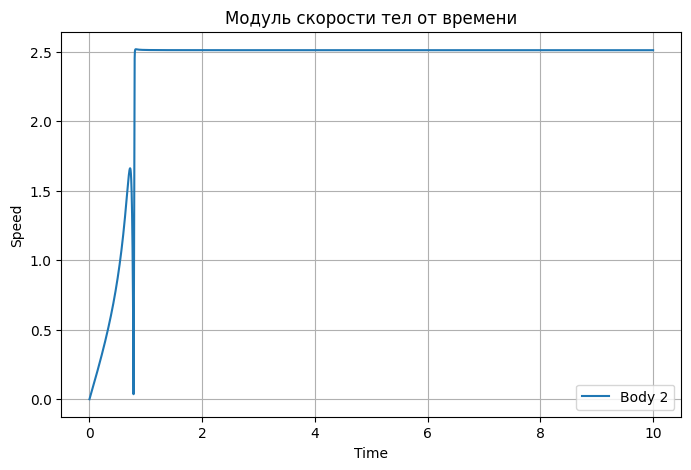

In [5]:
plt.figure(figsize=(8,5))
plt.plot(t, speed[:, 1], label=f'Body 2')
plt.xlabel("Time")
plt.ylabel("Speed")
plt.title("Модуль скорости тел от времени")
plt.legend()
plt.grid(True)
plt.show()

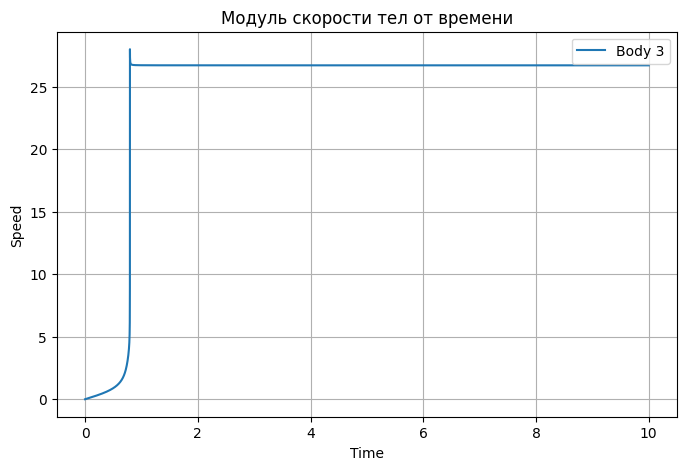

In [6]:
plt.figure(figsize=(8,5))
plt.plot(t, speed[:, 2], label=f'Body 3')
plt.xlabel("Time")
plt.ylabel("Speed")
plt.title("Модуль скорости тел от времени")
plt.legend()
plt.grid(True)
plt.show()